This notebook contains code for making and plotting baseline predictions.

In [ ]:
from ml_baselines.data import read_agage
from ml_baselines.modelling.plot import plot_confusion_matrix
from ml_baselines.modelling.predict import BaselineLabelledObservations, load_baseline_model, predict_baselines

from ml_baselines.config import Config
cfg = Config()

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Initialise and load model
site = "MHD"
model, extra_info = load_baseline_model(site=site, model_type=cfg.model_type, suffix="final", timestamp=None)

Loaded model from C:\Users\kirst\OneDrive\Kirstin\Uni\Year4\MSciProject\final_code\ml-baselines\models\MHD\mlp_model_2026-05-13_11-23_final.joblib


Predicting on full set for site: MHD with prediction threshold: 0.65
... loading full data for site: MHD, period: 1987-2024
Precision: 0.654
Recall: 0.479
F1 Score: 0.553


(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'MLP'}, xlabel='Predicted label', ylabel='InTEM label'>)

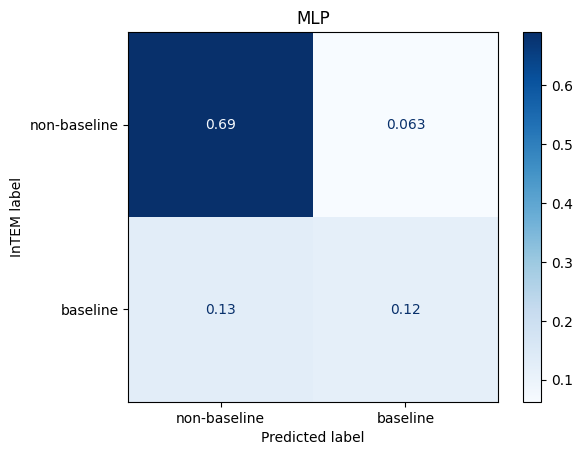

In [3]:
# Make predictions on all available data
y, y_pred, y_proba, ymetrics = predict_baselines(site=site, 
                                                 model=model, 
                                                 scaler=extra_info['scaler'],
                                                 prediction_mode="full", 
                                                 prediction_threshold=extra_info['model_inputs']['prediction_threshold'],
                                                 time_shift_hours=extra_info['model_inputs']['time_shift_hours'],
                                                 return_proba=True)

plot_confusion_matrix(y, y_pred, normalise=True, title=f"{cfg.model_type.upper() if cfg.model_type=='mlp' else cfg.model_type}")

## Predicting Baselines

In [4]:
# Load species data
species = "hfc-134a"
df_agage = read_agage(site, species.lower(), start_year=cfg.testing_period[site][0], end_year=cfg.testing_period[site][1])

# Extract baselines
labelled_obs = BaselineLabelledObservations(y, y_pred, df_agage, species=species.lower(), site=site, y_proba=y_proba)
labelled_obs.calculate_true_baseline_cv()
print('')
labelled_obs.get_prediction_scores()
print('')
labelled_obs.calculate_monthly_means()
print('')
labelled_obs.print_monthly_stats()

Baseline CV: 0.0027

train set - Precision: 0.780, Recall: 0.655, F1 Score: 0.712
valida set - Precision: 0.702, Recall: 0.567, F1 Score: 0.627
test set - Precision: 0.650, Recall: 0.472, F1 Score: 0.547
full set - Precision: 0.650, Recall: 0.472, F1 Score: 0.547

Found 9 missing months, and 52 anomaly months (with 44, 4, and 4 months with deviations greater than 1, 3, and 5 standard deviations respectively).

train set - MAE: 0.308, MAPE: 0.286%, bias: 0.238, RMSE: 0.670
valida set - MAE: 0.212, MAPE: 0.177%, bias: 0.165, RMSE: 0.264
test set - MAE: 0.264, MAPE: 0.904%, bias: 0.174, RMSE: 0.475
full set - MAE: 0.264, MAPE: 0.904%, bias: 0.174, RMSE: 0.475


## Plotting Predictions

#### High-frequency observations

(<Figure size 1200x600 with 1 Axes>,
 <Axes: ylabel='Molefraction in air / ppt'>)

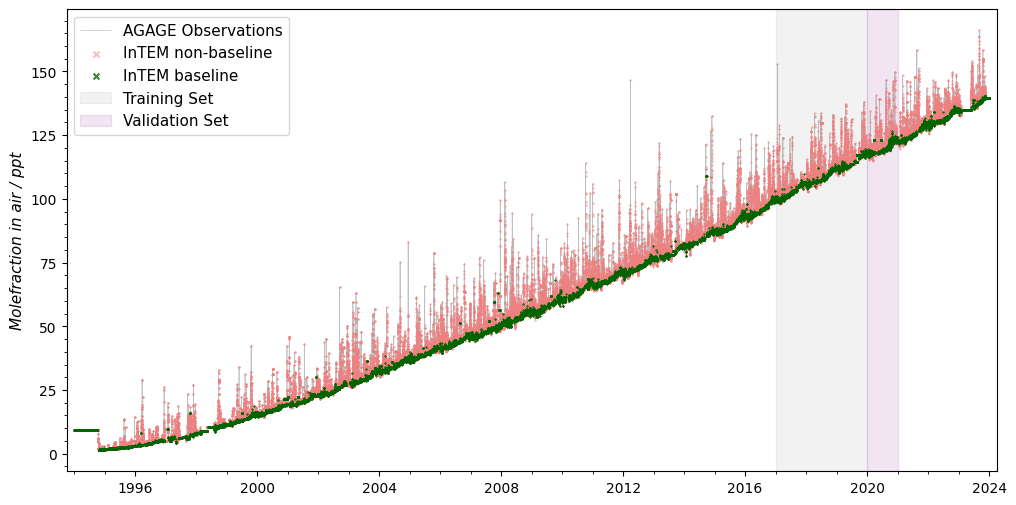

In [5]:
labelled_obs.plot_obs(title="", labels_from="InTEM",
                      shade_train_and_val_periods=True, show_legend=True)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: ylabel='Molefraction in air / ppt'>)

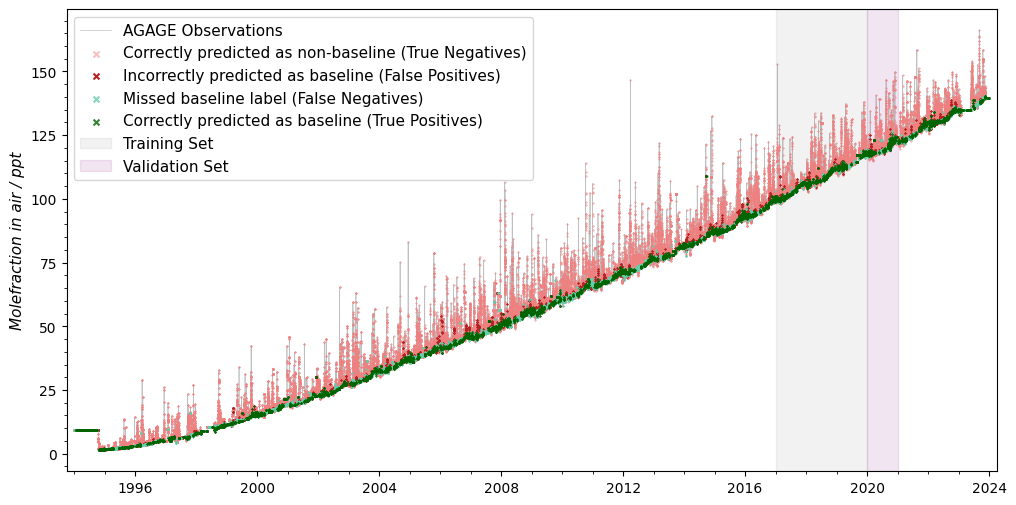

In [6]:
labelled_obs.plot_obs_with_labels(plot_true_negatives=True, title="", shade_train_and_val_periods=True)

(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': ' '}, ylabel='Molefraction in air / ppt'>)

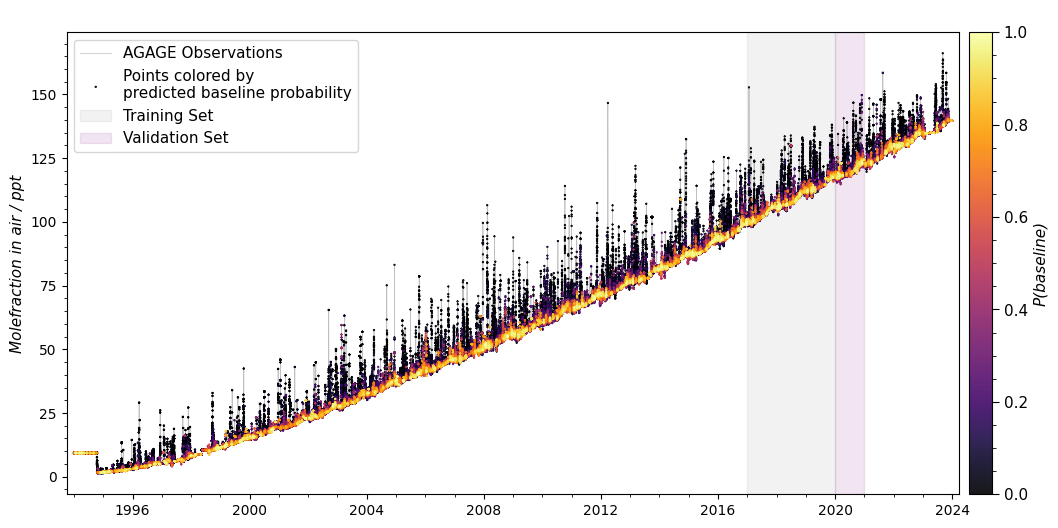

In [7]:
labelled_obs.plot_model_confidence(cmap="inferno", shade_train_and_val_periods=True, title=" ")

#### Monthly Means

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Mean Molefraction / ppt'>)

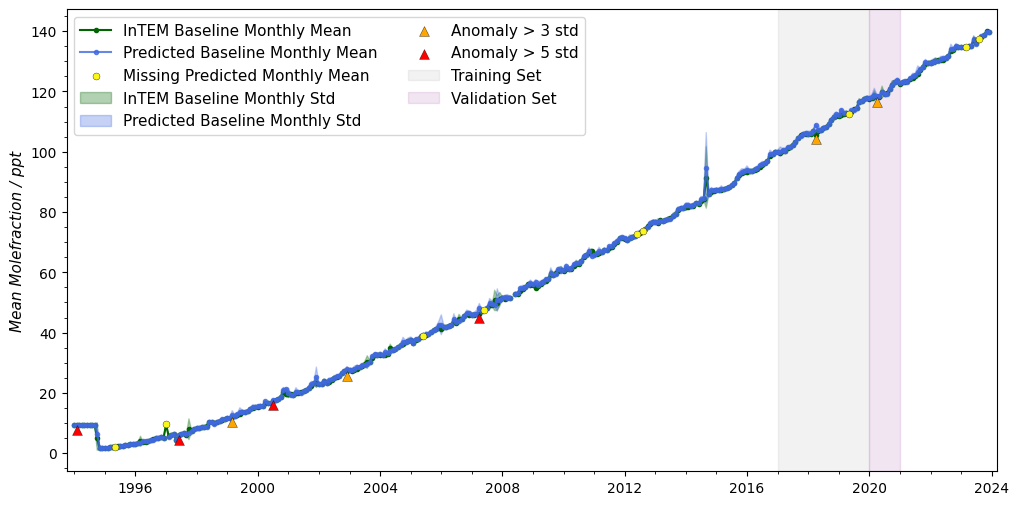

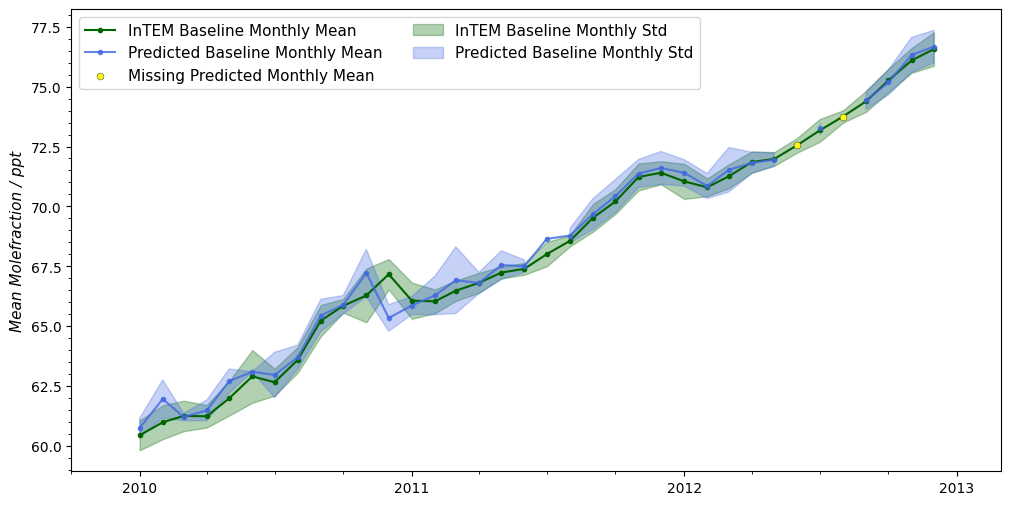

In [8]:
labelled_obs.plot_monthly_means(plot_obs=False,
                                plot_count_hist=False,
                                shade_train_and_val_periods=True,
                                show_anomalies=True,
                                show_missing=True,
                                title="",
                                show_legend=True)

labelled_obs.plot_monthly_means(plot_obs=False,
                                plot_count_hist=False,
                                shade_train_and_val_periods=True,
                                show_anomalies=True,
                                show_missing=True,
                                title="",
                                date_range=[2010,2012],
                                show_legend=True)